### 패키지 로드 및 데이터 전처리

In [1]:
# ==================================================
# 수업용 유틸 / 데이터 로드
# ==================================================
from hossam import *

# ==================================================
# 파이썬 기본 / 데이터 처리
# ==================================================
import numpy as np
from itertools import combinations
from pandas import DataFrame, concat, get_dummies

# ==================================================
# 시각화
# ==================================================
import seaborn as sb
from matplotlib import pyplot as plt

# ==================================================
# 통계 라이브러리
# ==================================================
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import (
    linear_reset,
    het_breuschpagan,
    het_white
)

from statsmodels.stats.stattools import durbin_watson

from pingouin import anova, welch_anova
from scipy.stats import (
    bartlett,
    jarque_bera,
    levene,
    normaltest,
    pearsonr,
    shapiro,
    spearmanr,
    t,
    ttest_ind,
    f,
)

# ==================================================
# sklearn - 파이프라인 / 전처리 / 모델 선택
# ==================================================
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    learning_curve,
)

# ==================================================
# sklearn - 회귀 모델
# ==================================================
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet,
    SGDRegressor,
)

# ==================================================
# sklearn - 성능 평가 지표
# ==================================================
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
)


## 미션1 
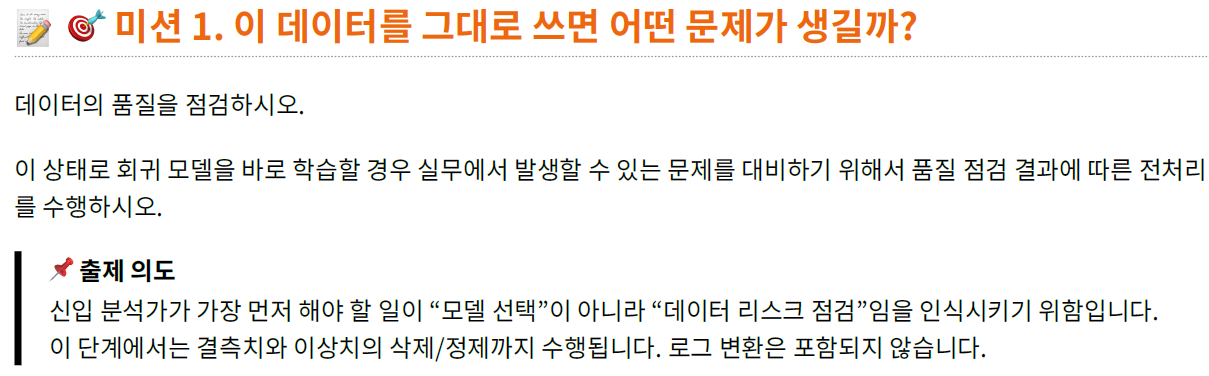

In [2]:
origin = load_data("restaurant_sales")


# 데이터 타입 변환 + 인덱스 설정
df1 = origin.astype(
    {
        "restaurant_type": "category",
        "holiday": "category",
        "weekend": "category",
    }
)

df1.set_index("date", inplace=True)

display(df1.info())
df1.head()





어느 식당의 1년간 일별 매출을 기록한 데이터로, 매출액을 종속변수로 하고 방문객 수, 객단가, 광고비, 날씨, 요일, 식당 유형 등의 정보를 포함함.

컬럼명           변수 타입    데이터 성격    설명
---------------  -----------  -------------  -------------------------------------------------------
date             날짜         시계열 인덱스  관측 날짜 (1년, 일 단위)
sales            연속형       수치           일 매출액 (종속변수). 이상치·왜도 존재 → 로그 변환 대상
visitors         연속형       수치           일 방문객 수. 매출과 강한 양의 관계
avg_price        연속형       수치           평균 객단가. 양의 왜도 → 로그 변환 권장
marketing_cost   연속형       수치           일 광고비 지출. 이상치·결측치 포함
delivery_ratio   연속형       비율           배달 매출 비중 (0~1). 비선형 효과 가능
rain_mm          연속형       수치           일 강수량(mm). 일부 결측치 존재
temperature      연속형       수치           일 평균 기온(℃). 계절성 반영
holiday          명목형       이진           공휴일 여부 (0=평일, 1=공휴일)
weekend          명목형       이진           주말 여부 (0=평일, 1=주말)
restaurant_type  명목형       범주           식당 유형 (한식/중식/양식/카페) → 원핫인코딩 필요

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 365 entries, 2024-01-01 to 20

None

,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend,restaurant_type
date,,,,,,,,,,
2024-01-01,10525760,122,14490,9900.0,0.48,6.0,5.2,0,0,한식
2024-01-02,8931390,106,11880,9400.0,0.48,7.0,11.1,0,0,중식
2024-01-03,12654970,120,18010,5800.0,0.43,12.4,12.9,1,0,한식
2024-01-04,9650090,115,11160,6300.0,0.41,6.6,12.9,0,0,중식
2024-01-05,9951380,124,15480,5400.0,0.51,8.0,11.0,0,0,카페


In [3]:
# 결측치 제거
n = len(df1)

missing_df = DataFrame(
    {
        "missing_count": df1.isnull().sum(),
    }
)

missing_df["missing_ratio"] = missing_df["missing_count"] / n

display(missing_df)

,missing_count,missing_ratio
sales,0,0.000000
visitors,0,0.000000
avg_price,0,0.000000
marketing_cost,6,0.016438
delivery_ratio,0,0.000000
rain_mm,6,0.016438
temperature,0,0.000000
holiday,0,0.000000
weekend,0,0.000000
restaurant_type,0,0.000000


### 독립검정 t-test함수 정의

In [4]:
def hs_ttest_ind(x_data, y_data):
    """
    두 집단 평균 차이에 대한 t-test 수행 함수
    - 정규성 판단 → 등분산성 판단 → Student / Welch t-test 선택
    """

    # ----------------------------------
    # 정규성 판별
    # ----------------------------------
    _, p1 = normaltest(x_data)
    _, p2 = normaltest(y_data)
    normal_dist = (p1 > 0.05) and (p2 > 0.05)

    # ----------------------------------
    # 등분산성 판별
    # ----------------------------------
    if normal_dist:
        method_name = "Bartlett"
        _, p = bartlett(x_data, y_data)
    else:
        method_name = "Levene"
        _, p = levene(x_data, y_data)

    equal_var = p > 0.05

    # ----------------------------------
    # 독립표본 t-test 수행
    # ----------------------------------
    alternatives = ["two-sided", "less", "greater"]
    result = []
    fmt = "μ(x) {} μ(y)"

    for a in alternatives:
        stat, p_value = ttest_ind(
            x_data,
            y_data,
            equal_var=equal_var,
            alternative=a,
        )

        test_name = "t-test_ind" if equal_var else "Welch's t-test"

        # ----------------------------------
        # 결과 해석
        # ----------------------------------
        if a == "two-sided":
            itp = fmt.format("==" if p_value > 0.05 else "!=")
        elif a == "less":
            itp = fmt.format(">=" if p_value > 0.05 else "<")
        else:
            itp = fmt.format("<=" if p_value > 0.05 else ">")

        result.append(
            {
                "test": test_name,
                "alternative": a,
                "interpretation": itp,
                "normal_test": normal_dist,
                "equal_variance": equal_var,
                "statistic": round(stat, 3),
                "p_value": round(p_value, 4),
                "H0": p_value > 0.05,
                "H1": p_value <= 0.05,
            }
        )

    rdf = DataFrame(result)
    rdf.set_index(["test", "alternative"], inplace=True)

    return rdf


### marketing_cost삭제 전후의 종속변수에 대해 평균적으로 유의미한 변화가 있는지 확인

In [5]:
df_temp = df1.dropna(
    subset=["marketing_cost"]
)

hs_ttest_ind(
    origin["sales"],
    df_temp["sales"],
)


interpretation  normal_test  equal_variance  statistic  \
test       alternative                                                          
t-test_ind two-sided     μ(x) == μ(y)        False            True     -0.041   
           less          μ(x) >= μ(y)        False            True     -0.041   
           greater       μ(x) <= μ(y)        False            True     -0.041   

                        p_value    H0     H1  
test       alternative                        
t-test_ind two-sided     0.9673  True  False  
           less          0.4836  True  False  
           greater       0.5164  True  False

### marketing_cost삭제 전후의 종속변수에 대해 평균적으로 유의미한 변화가 있는지 확인

In [6]:
df_temp =df1.dropna(subset=["marketing_cost"]) 
hs_ttest_ind(origin["sales"], df_temp["sales"])

interpretation  normal_test  equal_variance  statistic  \
test       alternative                                                          
t-test_ind two-sided     μ(x) == μ(y)        False            True     -0.041   
           less          μ(x) >= μ(y)        False            True     -0.041   
           greater       μ(x) <= μ(y)        False            True     -0.041   

                        p_value    H0     H1  
test       alternative                        
t-test_ind two-sided     0.9673  True  False  
           less          0.4836  True  False  
           greater       0.5164  True  False

In [7]:
hs_stats.ttest_ind(x=origin["sales"], y=df_temp["sales"])

interpretation  equal_var_checked  statistic  p-value  \
test       alternative                                                         
t-test_ind two-sided     μ(x) == μ(y)               True     -0.041   0.9673   
           less          μ(x) >= μ(y)               True     -0.041   0.4836   
           greater       μ(x) <= μ(y)               True     -0.041   0.5164   

                          H0     H1  
test       alternative               
t-test_ind two-sided    True  False  
           less         True  False  
           greater      True  False

### 모든 결측치 일괄 삭제 전후의 종속변수에 대해 평균적으로 유의미하 변화가 있는지 확인

In [8]:
# 결측치 제거
df1_clean = df1.dropna()

# 타깃 변수 분리
df1_target = df1_clean["sales"]
df_temp_target = df_temp["sales"]

# t-test 수행
hs_ttest_ind(df1_target, df_temp_target)


interpretation  normal_test  equal_variance  statistic  \
test       alternative                                                          
t-test_ind two-sided     μ(x) == μ(y)        False            True     -0.148   
           less          μ(x) >= μ(y)        False            True     -0.148   
           greater       μ(x) <= μ(y)        False            True     -0.148   

                        p_value    H0     H1  
test       alternative                        
t-test_ind two-sided     0.8825  True  False  
           less          0.4412  True  False  
           greater       0.5588  True  False

### 결측치 삭제

In [9]:
df2 = df1.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   sales            353 non-null    int64   
 1   visitors         353 non-null    int64   
 2   avg_price        353 non-null    int64   
 3   marketing_cost   353 non-null    float64 
 4   delivery_ratio   353 non-null    float64 
 5   rain_mm          353 non-null    float64 
 6   temperature      353 non-null    float64 
 7   holiday          353 non-null    category
 8   weekend          353 non-null    category
 9   restaurant_type  353 non-null    category
dtypes: category(3), float64(4), int64(3)
memory usage: 23.5 KB


### 이상치 확인 함수

In [10]:
from pandas import DataFrame


def hs_outlier_table(data: DataFrame) -> DataFrame:
    fields = data.select_dtypes(include="number").columns
    result = []

    for f in fields:
        # ── 사분위수
        q1 = data[f].quantile(0.25)
        q2 = data[f].quantile(0.50)
        q3 = data[f].quantile(0.75)

        min_value = data[f].min()
        max_value = data[f].max()

        # ── 이상치 경계 (Tukey's fences)
        iqr = q3 - q1
        down = q1 - 1.5 * iqr
        up = q3 + 1.5 * iqr

        # ── 왜도
        skew = data[f].skew()
        abs_skew = abs(skew)

        # ── 이상치 개수 / 비율
        outlier_count = ((data[f] < down) | (data[f] > up)).sum()
        outlier_rate = (outlier_count / len(data)) * 100

        # ── 분포 형태 분류 (왜도 기준)
        if abs_skew >= 0.5:
            if abs_skew >= 2.0:
                dist = "강한 우측 꼬리" if skew > 0 else "강한 좌측 꼬리"
            else:
                dist = "약한 우측 꼬리" if skew > 0 else "약한 좌측 꼬리"
        else:
            dist = "대칭 분포"

        # ── 로그 변환 필요성 판단
        if abs_skew >= 0.5:
            log_need = "높음"
        elif abs_skew >= 0.1:
            log_need = "중간"
        else:
            log_need = "낮음"

        # ── 결과 저장
        result.append({
            "field": f,
            "q1": q1,
            "q2": q2,
            "q3": q3,
            "iqr": iqr,
            "up": up,
            "down": down,
            "min": min_value,
            "max": max_value,
            "outlier_count": outlier_count,
            "outlier_rate": outlier_rate,
            "skew": skew,
            "dist": dist,
            "log_need": log_need,
        })

    return DataFrame(result).set_index("field")


### 연속형 변수에 대한 이상치 확인

In [11]:
outlier = hs_outlier_table(df2)
outlier

,q1,q2,q3,iqr,up,down,min,max,outlier_count,outlier_rate,skew,dist,log_need
field,,,,,,,,,,,,,
sales,9620430.00,12203340.00,16828290.00,7207860.00,2.764008e+07,-1191360.000,5972790.00,38585880.00,10,2.832861,1.256981,약한 우측 꼬리,높음
visitors,113.00,120.00,126.00,13.00,1.455000e+02,93.500,83.00,151.00,6,1.699717,-0.014914,대칭 분포,낮음
avg_price,12480.00,15340.00,17550.00,5070.00,2.515500e+04,4875.000,6330.00,27280.00,5,1.416431,0.471286,대칭 분포,중간
marketing_cost,4500.00,6800.00,10500.00,6000.00,1.950000e+04,-4500.000,1400.00,51700.00,12,3.399433,2.628738,강한 우측 꼬리,높음
delivery_ratio,0.36,0.45,0.53,0.17,7.850000e-01,0.105,0.17,0.77,0,0.000000,0.064028,대칭 분포,낮음
rain_mm,2.10,4.60,7.60,5.50,1.585000e+01,-6.150,0.00,20.00,8,2.266289,1.117849,약한 우측 꼬리,높음
temperature,-0.40,10.00,20.50,20.90,5.185000e+01,-31.750,-10.40,29.50,0,0.000000,0.011906,대칭 분포,낮음


 - 
 marketing_cost:일 광고비 지출. 이상치·결측치 포함<br>
 

## 미션2
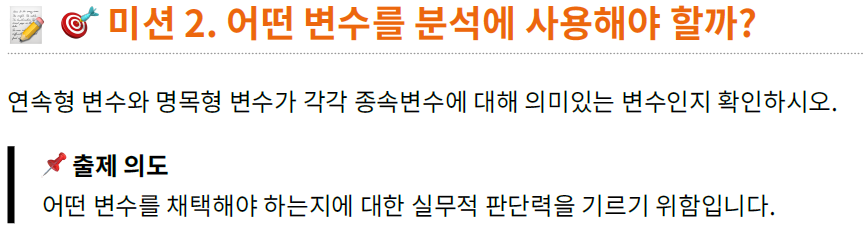

In [12]:
df2=df1.dropna()
df2.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 353 entries, 2024-01-01 to 2024-12-30
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   sales            353 non-null    int64   
 1   visitors         353 non-null    int64   
 2   avg_price        353 non-null    int64   
 3   marketing_cost   353 non-null    float64 
 4   delivery_ratio   353 non-null    float64 
 5   rain_mm          353 non-null    float64 
 6   temperature      353 non-null    float64 
 7   holiday          353 non-null    category
 8   weekend          353 non-null    category
 9   restaurant_type  353 non-null    category
dtypes: category(3), float64(4), int64(3)
memory usage: 23.5 KB


In [13]:
def hs_oneway_anova(
    data: DataFrame,
    dv: str,
    between: str,
    alpha: float = 0.05,
):
    # ===============================
    # 전처리
    # ===============================
    df_filtered = data[[dv, between]].dropna()

    # ===============================
    # 1. 정규성 검정 (각 그룹별)
    # ===============================
    group_names = sorted(df_filtered[between].unique())
    normality_satisfied = True

    for group in group_names:
        group_values = df_filtered.loc[
            df_filtered[between] == group, dv
        ].dropna()

        if len(group_values) > 0:
            _, p = normaltest(group_values)
            if p < alpha:
                normality_satisfied = False
                break

    # ===============================
    # 2. 등분산성 검정 (각 그룹별)
    # ===============================
    group_data_dict = {}

    for group in group_names:
        group_data_dict[group] = (
            df_filtered.loc[df_filtered[between] == group, dv]
            .dropna()
            .values
        )

    if len(group_names) > 1:
        if normality_satisfied:
            # 정규성 만족 → Bartlett
            s, p = bartlett(*group_data_dict.values())
            en = "Bartlett"
        else:
            # 정규성 불만족 → Levene
            s, p = levene(*group_data_dict.values())
            en = "Levene"

        equal_var_satisfied = p > alpha
    else:
        # 그룹이 1개인 경우 등분산 검정 불가
        equal_var_satisfied = True
        en = None

    # ===============================
    # 3. ANOVA 수행
    # ===============================
    if equal_var_satisfied:
        # 일반 ANOVA
        anova_method = "ANOVA"
        anova_df = anova(
            data=df_filtered,
            dv=dv,
            between=between,
        )
    else:
        # Welch ANOVA
        anova_method = "Welch"
        anova_df = welch_anova(
            data=df_filtered,
            dv=dv,
            between=between,
        )

    # ===============================
    # 결과 정리
    # ===============================
    anova_df.insert(1, "normality", normality_satisfied)
    anova_df.insert(2, en, equal_var_satisfied)

    if "p-unc" in anova_df.columns:
        anova_df["H0"] = anova_df["p-unc"] > alpha

    return anova_df


### 단일변수(restaurant_type)이 매출에 영향을 주는지 확인

In [14]:
origin.describe()

,date,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend
count,365,3.650000e+02,365.000000,365.000000,359.000000,365.000000,359.000000,365.000000,365.000000,365.000000
mean,2024-07-01 00:00:00.000000256,1.378779e+07,119.660274,15424.821918,8359.052925,0.447753,5.308914,9.895616,0.336986,0.284932
min,2024-01-01 00:00:00,5.972790e+06,83.000000,6330.000000,1400.000000,0.170000,0.000000,-10.400000,0.000000,0.000000
25%,2024-04-01 00:00:00,9.620430e+06,113.000000,12450.000000,4600.000000,0.370000,2.150000,-0.400000,0.000000,0.000000
50%,2024-07-01 00:00:00,1.233753e+07,120.000000,15340.000000,6900.000000,0.450000,4.600000,9.900000,0.000000,0.000000
75%,2024-09-30 00:00:00,1.682829e+07,126.000000,17570.000000,10600.000000,0.530000,7.600000,20.400000,1.000000,1.000000
max,2024-12-30 00:00:00,3.858588e+07,151.000000,27280.000000,51700.000000,0.770000,20.000000,29.500000,1.000000,1.000000
std,NaN,5.744793e+06,10.298815,3766.962411,5700.400132,0.117819,3.911683,10.706437,0.473329,0.452001


In [15]:
# 방법 1: groupby() 사용 (권장)
df2.groupby("restaurant_type").describe()

# 방법 2: 각 그룹별 통계량을 더 자세히 보기
for rt in df2["restaurant_type"].unique():
    print(f"\n{'='*50}")
    print(f"restaurant_type: {rt}")
    print(f"{'='*50}")
    print(df2[df2["restaurant_type"] == rt].describe())

# 방법 3: 특정 컬럼(예: sales)만 그룹별 분석
df2.groupby("restaurant_type")["sales"].describe()

# 방법 4: 여러 컬럼 선택 후 그룹별 분석
df2.groupby("restaurant_type")[["sales", "marketing_cost", "temperature"]].describe()


restaurant_type: 한식
              sales    visitors     avg_price  marketing_cost  delivery_ratio  \
count  1.010000e+02  101.000000    101.000000      101.000000      101.000000   
mean   1.386933e+07  120.544554  15409.900990     8108.415842        0.439307   
std    6.146214e+06   10.741997   3917.516431     4308.404979        0.123574   
min    5.972790e+06   83.000000   7290.000000     1400.000000        0.170000   
25%    9.707240e+06  114.000000  12860.000000     4800.000000        0.360000   
50%    1.236244e+07  121.000000  15170.000000     7000.000000        0.440000   
75%    1.658145e+07  128.000000  16900.000000    10900.000000        0.530000   
max    3.858588e+07  151.000000  27280.000000    24300.000000        0.730000   

          rain_mm  temperature  
count  101.000000   101.000000  
mean     4.949505     8.690099  
std      3.820435    10.878773  
min      0.000000   -10.400000  
25%      2.000000    -1.200000  
50%      4.200000     7.800000  
75%      6.800000 

C:\Users\itwill\AppData\Local\Temp\ipykernel_23572\4100586872.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby("restaurant_type").describe()
C:\Users\itwill\AppData\Local\Temp\ipykernel_23572\4100586872.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby("restaurant_type")["sales"].describe()
C:\Users\itwill\AppData\Local\Temp\ipykernel_23572\4100586872.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence thi

sales                                                     \
                 count          mean           std        min         25%   
restaurant_type                                                             
양식                88.0  1.403106e+07  5.537822e+06  6164560.0  10041432.5   
중식                82.0  1.338523e+07  5.159259e+06  5985120.0   9570792.5   
카페                82.0  1.363124e+07  5.892329e+06  6348660.0   9181572.5   
한식               101.0  1.386933e+07  6.146214e+06  5972790.0   9707240.0   

                                                    marketing_cost  \
                        50%         75%         max          count   
restaurant_type                                                      
양식               12660735.0  17132670.0  31405100.0           88.0   
중식               12508740.0  15775515.0  28441980.0           82.0   
카페               11190080.0  17422165.0  32640380.0           82.0   
한식               12362440.0  16581450.0  38585880.0          101.0   

                                                                            \
                        mean          std     min     25%     50%      75%   
restaurant_type                                                              
양식               8933.522727  6114.767886  2200.0  4900.0  7050.0  10050.0   
중식               8103.658537  6553.755782  1700.0  4100.0  6250.0  10125.0   
카페               8060.975610  5763.631316  1400.0  4500.0  6750.0   9400.0   
한식               8108.415842  4308.404979  1400.0  4800.0  7000.0  10900.0   

                         temperature                                     \
                     max       count       mean        std   min    25%   
restaurant_type                                                           
양식               35200.0        88.0  10.430682  10.150130 -10.3  0.550   
중식               51700.0        82.0   9.479268  10.977359  -7.8 -1.300   
카페               34800.0        82.0  11.560976  10.855388  -6.6  2.225   
한식               24300.0       101.0   8.690099  10.878773 -10.4 -1.200   

                                     
                   50%    75%   max  
restaurant_type                      
양식               11.05  19.15  27.4  
중식               10.50  20.95  27.7  
카페               10.95  21.90  27.7  
한식                7.80  18.70  29.5

In [16]:
import pandas as pd
# 방법 1: 기본 출력
df2.groupby("restaurant_type")["sales"].describe()

# 방법 2: 과학적 표기법 제거 (권장)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
df2.groupby("restaurant_type")["sales"].describe()

# 방법 3: 각 그룹별로 명확하게 출력
for rt in df2["restaurant_type"].unique():
    print(f"\n{rt}:")
    print(df2[df2["restaurant_type"] == rt]["sales"].describe())


한식:
count          101.00
mean    13,869,328.91
std      6,146,214.12
min      5,972,790.00
25%      9,707,240.00
50%     12,362,440.00
75%     16,581,450.00
max     38,585,880.00
Name: sales, dtype: float64

중식:
count           82.00
mean    13,385,225.49
std      5,159,258.65
min      5,985,120.00
25%      9,570,792.50
50%     12,508,740.00
75%     15,775,515.00
max     28,441,980.00
Name: sales, dtype: float64

카페:
count           82.00
mean    13,631,242.93
std      5,892,329.26
min      6,348,660.00
25%      9,181,572.50
50%     11,190,080.00
75%     17,422,165.00
max     32,640,380.00
Name: sales, dtype: float64

양식:
count           88.00
mean    14,031,056.52
std      5,537,821.64
min      6,164,560.00
25%     10,041,432.50
50%     12,660,735.00
75%     17,132,670.00
max     31,405,100.00
Name: sales, dtype: float64


C:\Users\itwill\AppData\Local\Temp\ipykernel_23572\3791326051.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby("restaurant_type")["sales"].describe()
C:\Users\itwill\AppData\Local\Temp\ipykernel_23572\3791326051.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df2.groupby("restaurant_type")["sales"].describe()


### 더미 변수를 포함한 다중선형회귀

In [17]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import pandas as pd

# ----------------------------------
# 데이터 준비
# ----------------------------------
X = pd.get_dummies(df2.drop(columns=['sales']), drop_first=True)
y = df2['sales']

# ----------------------------------
# 훈련/테스트 분할
# ----------------------------------
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ----------------------------------
# 파이프라인 (스케일링 + 회귀)
# ----------------------------------
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipe.fit(X_train, y_train)

# ----------------------------------
# 과적합 진단
# ----------------------------------
train_score = pipe.score(X_train, y_train)
test_score = pipe.score(X_test, y_test)

print(f"훈련 R²: {train_score:.4f}")
print(f"테스트 R²: {test_score:.4f}")
print(f"과적합 정도: {train_score - test_score:.4f}")

if train_score - test_score > 0.1:
    print("⚠️ 과적합 의심!")
else:
    print("✅ 적절한 수준")

print(f"restaurant_type별로 통계적 유의성이 확인되지 않아서 과적합이 적절한 수준으로 나온걸까?")

훈련 R²: 0.7271
테스트 R²: 0.6729
과적합 정도: 0.0541
✅ 적절한 수준
restaurant_type별로 통계적 유의성이 확인되지 않아서 과적합이 적절한 수준으로 나온걸까?


### restaurant_type별 개별 분석

In [18]:
hs_oneway_anova(df2,dv="sales",between="restaurant_type")

,Source,normality,Levene,ddof1,ddof2,F,p-unc,np2,H0
0,restaurant_type,False,True,3,349,0.21,0.89,0.00,True


### 모든 명목형 변수에 대해 매출에 영향을 주는 변수인지 일괄 확인

In [19]:
anova_df = None

fields = df2.dtypes[df2.dtypes == "category"].index.tolist()

for f in fields:
    anova_result = hs_oneway_anova(df2, dv="sales", between=f)

    if anova_df is None:
        anova_df = anova_result
    else:
        anova_df = concat([anova_df, anova_result], ignore_index=True)

anova_df


,Source,normality,Levene,ddof1,ddof2,F,p-unc,np2,H0
0,holiday,False,False,1,152.17,256.19,0.00,0.51,False
1,weekend,False,False,1,129.57,299.61,0.00,0.56,False
2,restaurant_type,False,True,3,349.00,0.21,0.89,0.00,True


### 쌍별 상관분석 함수

In [20]:
def hs_corr_pairwise(data: DataFrame):
    alpha = 0.05          # 유의수준
    z_thresh = 3          # 이상치 판단 기준 (z-score)
    min_n = 8             # 최소 샘플 크기

    # 수치형 변수 선택
    cols = data.select_dtypes(include=[np.number]).columns.tolist()
    if len(cols) < 2:
        raise ValueError("수치형 변수가 두 개 이상 있어야 상관분석 가능")

    # 변수별 이상치 여부 판단
    z_outlier_flags = {}
    for col in cols:
        col_data = data[col].dropna()
        if col_data.std(ddof=1) == 0:
            z_outlier_flags[col] = False
            continue

        z = (col_data - col_data.mean()) / col_data.std(ddof=1)
        z_outlier_flags[col] = (np.abs(z) > z_thresh).any()

    rows = []

    for a, b in combinations(cols, 2):
        pair_df = data[[a, b]].dropna()

        # 샘플 수 부족
        if len(pair_df) < min_n:
            rows.append({
                "var_a": a,
                "var_b": b,
                "n": len(pair_df),
                "linearity": False,
                "outlier_flag": True,
                "chosen": None,
                "corr": np.nan,
                "pval": np.nan,
                "significant": False,
                "strength": "no correlation",
            })
            continue

        x = pair_df[a]
        y = pair_df[b]

        # 1️⃣ 선형성 검사 (OLS 잔차 Shapiro)
        linearity_ok = False
        try:
            X_const = sm.add_constant(x)
            model = sm.OLS(y, X_const).fit()
            _, p_resid = shapiro(model.resid)
            linearity_ok = p_resid > alpha
        except Exception:
            linearity_ok = False

        # 2️⃣ 이상치 여부
        outlier_flag = (
            z_outlier_flags.get(a, False)
            or z_outlier_flags.get(b, False)
        )

        # 3️⃣ 상관계수 선택
        try:
            if linearity_ok and not outlier_flag:
                chosen = "pearson"
                corr_val, pval = pearsonr(x, y)
            else:
                chosen = "spearman"
                corr_val, pval = spearmanr(x, y)
        except Exception:
            chosen = None
            corr_val, pval = np.nan, np.nan

        # 4️⃣ 유의성 및 강도
        significant = False if np.isnan(pval) else pval <= alpha
        abs_r = abs(corr_val) if not np.isnan(corr_val) else 0

        if abs_r >= 0.7:
            strength = "strong"
        elif abs_r >= 0.3:
            strength = "medium"
        elif abs_r > 0:
            strength = "weak"
        else:
            strength = "no correlation"

        rows.append({
            "var_a": a,
            "var_b": b,
            "n": len(pair_df),
            "linearity": linearity_ok,
            "outlier_flag": outlier_flag,
            "chosen": chosen,
            "corr": corr_val,
            "pval": pval,
            "significant": significant,
            "strength": strength,
        })

    result_df = DataFrame(rows)

    # 5️⃣ 상관행렬 생성
    corr_matrix = DataFrame(np.nan, index=cols, columns=cols)
    for col in cols:
        corr_matrix.loc[col, col] = 1.0

    if not result_df.empty:
        for _, row in result_df.iterrows():
            a, b, r = row["var_a"], row["var_b"], row["corr"]
            corr_matrix.loc[a, b] = r
            corr_matrix.loc[b, a] = r

    return result_df, corr_matrix


In [21]:
corr, matrix = hs_corr_pairwise(df2.drop("sales", axis=1))

display(corr)
display(matrix)


,var_a,var_b,n,linearity,outlier_flag,chosen,corr,pval,significant,strength
0,visitors,avg_price,353,False,True,spearman,0.05,0.38,False,weak
1,visitors,marketing_cost,353,False,True,spearman,0.02,0.66,False,weak
2,visitors,delivery_ratio,353,True,True,spearman,0.11,0.05,True,weak
3,visitors,rain_mm,353,False,True,spearman,0.05,0.40,False,weak
4,visitors,temperature,353,False,True,spearman,-0.02,0.69,False,weak
5,avg_price,marketing_cost,353,False,True,spearman,0.06,0.29,False,weak
6,avg_price,delivery_ratio,353,True,True,spearman,-0.02,0.73,False,weak
7,avg_price,rain_mm,353,False,True,spearman,0.09,0.08,False,weak
8,avg_price,temperature,353,False,True,spearman,-0.01,0.87,False,weak
9,marketing_cost,delivery_ratio,353,True,True,spearman,-0.01,0.87,False,weak


,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature
visitors,1.00,0.05,0.02,0.11,0.05,-0.02
avg_price,0.05,1.00,0.06,-0.02,0.09,-0.01
marketing_cost,0.02,0.06,1.00,-0.01,-0.01,-0.03
delivery_ratio,0.11,-0.02,-0.01,1.00,0.05,0.03
rain_mm,0.05,0.09,-0.01,0.05,1.00,0.06
temperature,-0.02,-0.01,-0.03,0.03,0.06,1.00


## date를 4분위수로 쪼갬

In [22]:
import pandas as pd
from pandas import DataFrame

# ----------------------------------
# date를 4분위수로 쪼개기
# ----------------------------------
# date를 숫자로 변환 (분석 용이)
df2['date_numeric'] = pd.to_datetime(df2.index).astype('int64')

# qcut()을 사용하여 4분위수로 나누기
df2['date_quartile'] = pd.qcut(
    df2['date_numeric'], 
    q=4, 
    labels=['Q1 (초기)', 'Q2 (중기)', 'Q3 (후기)', 'Q4 (최종)']
)

# ----------------------------------
# 분위별 기본 통계
# ----------------------------------
print("=== date 분위별 통계 ===")
print(df2.groupby('date_quartile')[['sales', 'marketing_cost', 'temperature', 'delivery_ratio']].describe())

# ----------------------------------
# 분위별 평균값 비교
# ----------------------------------
print("\n=== date 분위별 평균값 ===")
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
quartile_means = df2.groupby('date_quartile')[df2.select_dtypes(include=[np.number]).columns].mean()
display(quartile_means)

# ----------------------------------
# 분위별 표본 수
# ----------------------------------
print("\n=== date 분위별 표본 수 ===")
print(df2['date_quartile'].value_counts().sort_index())


# ----------------------------------
# 분위별 상관분석
# ----------------------------------
print("\n=== date 분위별 상관계수 (sales 기준) ===")
for quartile in ['Q1 (초기)', 'Q2 (중기)', 'Q3 (후기)', 'Q4 (최종)']:
    df_q = df2[df2['date_quartile'] == quartile]
    numeric_cols = df_q.select_dtypes(include=[np.number]).columns.tolist()
    
    if 'sales' in numeric_cols:
        print(f"\n{quartile}:")
        corr_with_sales = df_q[numeric_cols].corr()['sales'].sort_values(ascending=False)
        print(corr_with_sales)

=== date 분위별 통계 ===
              sales                                                       \
              count          mean          std          min          25%   
date_quartile                                                              
Q1 (초기)       89.00 13,595,837.53 5,990,010.07 6,164,560.00 9,261,740.00   
Q2 (중기)       88.00 14,097,206.02 5,699,812.68 6,455,570.00 9,945,732.50   
Q3 (후기)       88.00 14,038,077.27 6,510,671.06 5,972,790.00 9,506,310.00   
Q4 (최종)       88.00 13,238,081.07 4,445,891.70 6,348,660.00 9,860,787.50   

                                                        marketing_cost  \
                        50%           75%           max          count   
date_quartile                                                            
Q1 (초기)       11,599,660.00 16,282,450.00 31,405,100.00          89.00   
Q2 (중기)       12,671,085.00 17,500,780.00 36,489,250.00          88.00   
Q3 (후기)       12,521,195.00 16,619,585.00 38,585,880.00          88.00   
Q4 

C:\Users\itwill\AppData\Local\Temp\ipykernel_23572\3399651812.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['date_numeric'] = pd.to_datetime(df2.index).astype('int64')
C:\Users\itwill\AppData\Local\Temp\ipykernel_23572\3399651812.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['date_quartile'] = pd.qcut(
C:\Users\itwill\AppData\Local\Temp\ipykernel_23572\3399651812.py:21: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. 

,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,date_numeric
date_quartile,,,,,,,,
Q1 (초기),"13,595,837.53",119.63,"14,967.98","7,955.06",0.45,5.65,19.49,"1,708,019,271,910,112,256.00"
Q2 (중기),"14,097,206.02",119.31,"15,802.61","8,230.68",0.44,5.22,19.31,"1,715,836,254,545,454,592.00"
Q3 (후기),"14,038,077.27",121.22,"15,098.18","8,934.66",0.43,5.34,0.51,"1,723,801,745,454,545,408.00"
Q4 (최종),"13,238,081.07",118.17,"15,707.73","8,091.48",0.46,5.02,0.47,"1,731,705,381,818,181,888.00"



=== date 분위별 표본 수 ===
date_quartile
Q1 (초기)    89
Q2 (중기)    88
Q3 (후기)    88
Q4 (최종)    88
Name: count, dtype: int64

=== date 분위별 상관계수 (sales 기준) ===

Q1 (초기):
sales             1.00
marketing_cost    0.35
visitors          0.34
avg_price         0.11
temperature      -0.05
delivery_ratio   -0.06
date_numeric     -0.07
rain_mm          -0.32
Name: sales, dtype: float64

Q2 (중기):
sales             1.00
avg_price         0.26
marketing_cost    0.16
visitors          0.08
temperature       0.05
date_numeric      0.00
delivery_ratio   -0.20
rain_mm          -0.28
Name: sales, dtype: float64

Q3 (후기):
sales             1.00
marketing_cost    0.27
avg_price         0.23
temperature       0.09
delivery_ratio    0.01
visitors         -0.01
date_numeric     -0.04
rain_mm          -0.19
Name: sales, dtype: float64

Q4 (최종):
sales             1.00
avg_price         0.28
marketing_cost    0.24
delivery_ratio    0.04
visitors          0.01
temperature      -0.03
date_numeric     -0.04
rain_mm   

### 4분위수별 date 보기

In [23]:
# ----------------------------------
# date 분위별 날짜 범위 요약
# ----------------------------------
print("\n=== date 분위별 날짜 범위 ===")

for quartile in ['Q1 (초기)', 'Q2 (중기)', 'Q3 (후기)', 'Q4 (최종)']:
    dates = df2.loc[df2['date_quartile'] == quartile].index
    
    print(
        f"{quartile}: "
        f"{dates.min().strftime('%Y-%m-%d')} ~ {dates.max().strftime('%Y-%m-%d')} "
        f"({len(dates)}일)"
    )




=== date 분위별 날짜 범위 ===
Q1 (초기): 2024-01-01 ~ 2024-04-01 (89일)
Q2 (중기): 2024-04-02 ~ 2024-06-30 (88일)
Q3 (후기): 2024-07-02 ~ 2024-10-02 (88일)
Q4 (최종): 2024-10-03 ~ 2024-12-30 (88일)


## 📊 date 사분위수(Q1~Q4) 기반 상관관계 분석 인사이트 (sales 기준)

### 🔹 분석 개요
- 전체 기간(365일)을 `date` 기준으로 **사분위수(Q1~Q4)**로 분할
- 각 기간별로 `sales`와 주요 연속형 변수 간 **상관계수(Pearson)** 비교
- 목적: **시간 흐름에 따라 sales의 결정 요인이 어떻게 달라지는지** 파악

---

## 1️⃣ Q1 (초기 구간)

**주요 특징**
- `marketing_cost` (0.35), `visitors` (0.34)가 sales와 가장 높은 양의 상관
- `rain_mm`는 비교적 뚜렷한 음의 상관 (-0.32)
- `temperature`는 매우 약한 음의 상관 (-0.05)

**해석**
- 초기에는 **외부 환경보다 내부 운영 변수(마케팅, 방문자 수)**가 매출에 더 직접적인 영향을 미침
- 기온이 낮거나 변동성이 큰 시기일 가능성이 있으며,
  이에 따라 **마케팅 비용을 통해 수요를 보완하려는 전략**이 사용된 것으로 해석 가능
- 강수량 증가는 외출·방문 감소 → 매출 감소로 연결되는 전형적 패턴

---

## 2️⃣ Q2 (중기 구간)

**주요 특징**
- `avg_price` (0.26)가 sales와 가장 높은 상관
- `temperature`는 약한 양의 상관 (0.05)
- `delivery_ratio` (-0.20), `rain_mm` (-0.28)는 음의 상관 유지

**해석**
- 기온이 점진적으로 상승하는 시기로 보이며,
  이에 따라 **방문 수요가 회복되면서 가격 인상 여지가 발생**
- 방문자 수 자체의 상관은 크지 않지만,
  **가격 전략(avg_price)이 매출에 더 직접적으로 기여**
- 배달 비중과 매출 간 음의 상관은
  → 오프라인 소비 회복 국면 가능성 시사

---

## 3️⃣ Q3 (후기 구간)

**주요 특징**
- `marketing_cost` (0.27), `avg_price` (0.23)가 핵심 변수
- `temperature`는 여전히 약한 양의 상관 (0.09)
- `visitors`, `delivery_ratio`는 거의 무상관

**해석**
- 기온 상승 효과는 유지되지만,
  **자연 유입(visitor)보다는 가격·마케팅 전략이 매출을 좌우**
- 수요가 어느 정도 포화된 상태에서
  → **단가 조정과 프로모션이 매출 조절 수단**으로 작동

---

## 4️⃣ Q4 (최종 구간)

**주요 특징**
- `avg_price` (0.28), `marketing_cost` (0.24)가 여전히 상위
- `temperature`는 다시 약한 음의 상관 (-0.03)
- `rain_mm`는 지속적인 음의 상관 (-0.21)

**해석**
- 계절 전환 또는 수요 둔화 구간으로 해석 가능
- 기온 효과는 약화되고,
  **가격 전략과 마케팅 비용이 매출 방어 역할**
- 외부 환경(강수)의 부정적 영향이 다시 부각

---

## 🧠 종합 인사이트 요약

- 전체적으로 **환경 변수(temperature, rain_mm)는 단독 영향력이 약함**
- 시간 흐름에 따라 sales의 핵심 결정 요인이 변화:
  - 초기: 마케팅·유입 중심
  - 중기: 가격 전략 강화
  - 후기~말기: 가격 + 마케팅에 의한 매출 방어
- 이는 **현실적인 비즈니스 데이터에서 매우 자연스러운 구조**
  (→ 다중공선성 낮고, 변수 역할 분담이 명확)

---

## 📌 분석 확장 제안
- `temperature × weekend`, `rain_mm × delivery_ratio` 상호작용 분석
- 분기별 회귀계수 비교 (OLS or Ridge)
- 분기 단위 평균값 변화 시각화 (trend 분석)



### delivery_ratio의 outlier_flag가 확인 안 된 이유

In [24]:
# delivery_ratio의 기본 정보
print("=== delivery_ratio 상세 분석 ===")
print(f"데이터 개수: {len(df2['delivery_ratio'])}")
print(f"결측치: {df2['delivery_ratio'].isnull().sum()}")
print(f"표준편차: {df2['delivery_ratio'].std():.4f}")
print(f"최소값: {df2['delivery_ratio'].min():.4f}")
print(f"최대값: {df2['delivery_ratio'].max():.4f}")

# 각 변수별로 delivery_ratio와의 결합 상태 확인
print("\n=== delivery_ratio 쌍별 조합 ===")
for col in df2.select_dtypes(include=[np.number]).columns:
    if col != 'delivery_ratio':
        valid_n = df2[['delivery_ratio', col]].dropna().shape[0]
        print(f"delivery_ratio + {col}: n={valid_n}")

=== delivery_ratio 상세 분석 ===
데이터 개수: 353
결측치: 0
표준편차: 0.1184
최소값: 0.1700
최대값: 0.7700

=== delivery_ratio 쌍별 조합 ===
delivery_ratio + sales: n=353
delivery_ratio + visitors: n=353
delivery_ratio + avg_price: n=353
delivery_ratio + marketing_cost: n=353
delivery_ratio + rain_mm: n=353
delivery_ratio + temperature: n=353
delivery_ratio + date_numeric: n=353


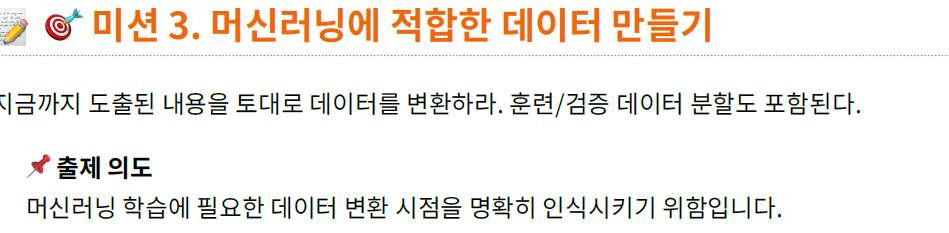

### ANOVA결과 반영

In [25]:
# 영향을 주지 않는 변수 제거
df3 = df2.drop("restaurant_type",axis=1)

display(df3.head())

,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,holiday,weekend,date_numeric,date_quartile
date,,,,,,,,,,,
2024-01-01,10525760,122,14490,"9,900.00",0.48,6.00,5.20,0,0,1704067200000000000,Q1 (초기)
2024-01-02,8931390,106,11880,"9,400.00",0.48,7.00,11.10,0,0,1704153600000000000,Q1 (초기)
2024-01-03,12654970,120,18010,"5,800.00",0.43,12.40,12.90,1,0,1704240000000000000,Q1 (초기)
2024-01-04,9650090,115,11160,"6,300.00",0.41,6.60,12.90,0,0,1704326400000000000,Q1 (초기)
2024-01-05,9951380,124,15480,"5,400.00",0.51,8.00,11.00,0,0,1704412800000000000,Q1 (초기)


### 로그 변환

In [26]:
# 2. 로그 변환 대상 변수 선택
log_fields = outlier[outlier["log_need"] != "낮음"].index.tolist()

# 3. 로그 변환 적용
for col in log_fields:
    df3[col] = np.log1p(df3[col])

# 4. 변환 후 이상치 재확인
outlier_after = hs_outlier_table(df3)
display(outlier_after)


,q1,q2,q3,iqr,up,down,min,max,outlier_count,outlier_rate,skew,dist,log_need
field,,,,,,,,,,,,,
sales,16.08,16.32,16.64,0.56,17.48,15.24,15.60,17.47,0,0.00,0.39,대칭 분포,중간
visitors,113.00,120.00,126.00,13.00,145.50,93.50,83.00,151.00,6,1.70,-0.01,대칭 분포,낮음
avg_price,9.43,9.64,9.77,0.34,10.28,8.92,8.75,10.21,3,0.85,-0.21,대칭 분포,중간
marketing_cost,8.41,8.82,9.26,0.85,10.53,7.14,7.24,10.85,1,0.28,0.10,대칭 분포,낮음
delivery_ratio,0.36,0.45,0.53,0.17,0.79,0.10,0.17,0.77,0,0.00,0.06,대칭 분포,낮음
rain_mm,1.13,1.72,2.15,1.02,3.68,-0.40,0.00,3.04,0,0.00,-0.30,대칭 분포,중간
temperature,-0.40,10.00,20.50,20.90,51.85,-31.75,-10.40,29.50,0,0.00,0.01,대칭 분포,낮음
date_numeric,"1,711,929,600,000,000,000.00","1,719,705,600,000,000,000.00","1,727,827,200,000,000,000.00","15,897,600,000,000,000.00","1,751,673,600,000,000,000.00","1,688,083,200,000,000,000.00","1,704,067,200,000,000,000.00","1,735,516,800,000,000,000.00",0,0.00,0.01,대칭 분포,낮음


### 더미변수 처리

In [27]:
df4 = get_dummies(df3, columns=["holiday", "weekend"], drop_first=False, dtype="int")
df4.head()

,sales,visitors,avg_price,marketing_cost,delivery_ratio,rain_mm,temperature,date_numeric,date_quartile,holiday_0,holiday_1,weekend_0,weekend_1
date,,,,,,,,,,,,,
2024-01-01,16.17,122,9.58,9.20,0.48,1.95,5.20,1704067200000000000,Q1 (초기),1,0,1,0
2024-01-02,16.01,106,9.38,9.15,0.48,2.08,11.10,1704153600000000000,Q1 (초기),1,0,1,0
2024-01-03,16.35,120,9.80,8.67,0.43,2.60,12.90,1704240000000000000,Q1 (초기),0,1,1,0
2024-01-04,16.08,115,9.32,8.75,0.41,2.03,12.90,1704326400000000000,Q1 (초기),1,0,1,0
2024-01-05,16.11,124,9.65,8.59,0.51,2.20,11.00,1704412800000000000,Q1 (초기),1,0,1,0


### 전처리 완료 데이터셋 저장

In [28]:
df4.to_excel("restaurant_sales_preprocessed.xlsx")

## 미션4
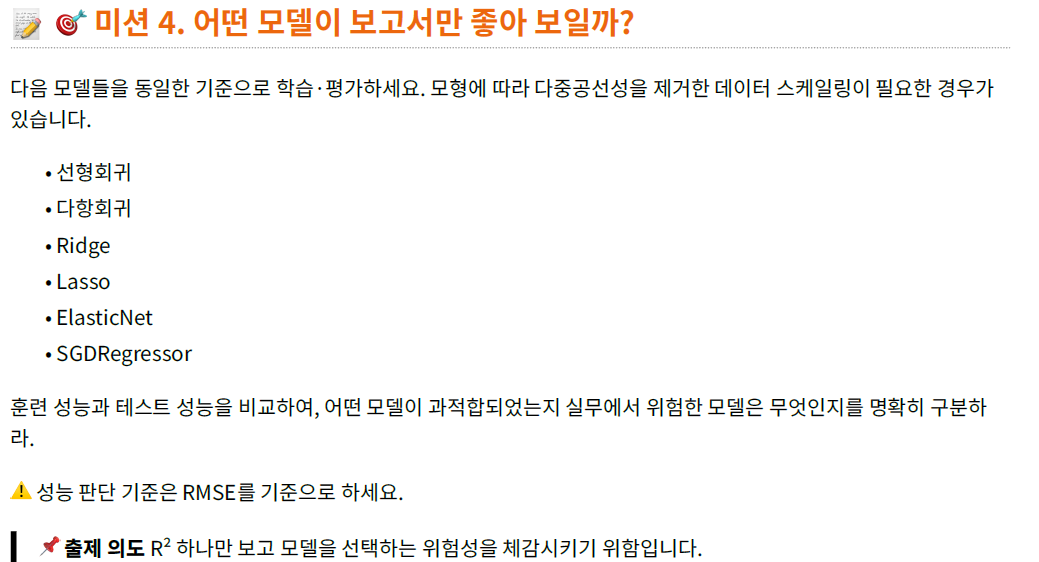

### 훈련, 검증 데이터 분리

In [29]:
# 원본 보호를 위한 복사
df = df4.copy()

# 타깃 / 피처 분리
y_name = "sales"
X = df.drop(y_name,axis=1)
y = df[y_name]

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=52
)

# 데이터 크기 확인
X_train.shape, X_test.shape, y_train.shape, y_test.shape


((264, 12), (89, 12), (264,), (89,))

### 다중선형회귀
### VIF 필터링 클래스 작성하기

In [30]:
from sklearn.base import BaseEstimator, TransformerMixin


class CustomTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, param1=None, param2=None):
        self.param1 = param1
        self.param2 = param2

    def fit(self, X, y=None):
        """
        데이터로부터 규칙(통계량 등)을 학습
        """
        # self.some_stat_ = ...
        return self

    def transform(self, X):
        """
        fit에서 학습한 규칙을 기반으로 변환 수행
        """
        X_transformed = X.copy()
        return X_transformed


In [31]:
from sklearn.base import BaseEstimator, TransformerMixin
from pandas import DataFrame
from IPython.display import display

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


class VIFSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold: float = 10.0, check_cols=None):
        self.threshold = threshold
        self.check_cols = check_cols

    def _compute_vifs(self, X: DataFrame) -> DataFrame:
        exog = sm.add_constant(X, prepend=True)
        vifs = {}

        for i, col in enumerate(X.columns):
            try:
                vifs[col] = float(
                    variance_inflation_factor(exog.values, i + 1)
                )
            except Exception:
                vifs[col] = float("inf")

        vdf = DataFrame(
            vifs.items(),
            columns=["Variable", "VIF"]
        ).sort_values("VIF", ascending=False)

        return vdf

    def fit(self, X, y=None):
        df = X.copy().dropna()

        self.vif_cols_ = (
            self.check_cols
            if self.check_cols is not None
            else df.columns.tolist()
        )

        X_vif = df[self.vif_cols_].copy()
        self.drop_cols_ = []

        step = 1
        while True:
            if X_vif.shape[1] == 0:
                break

            print(f"\n===== VIF 제거 단계 {step} =====")
            vdf = self._compute_vifs(X_vif)
            display(vdf)

            max_vif = vdf.iloc[0]["VIF"]
            max_col = vdf.iloc[0]["Variable"]

            if max_vif <= self.threshold:
                print(
                    f"모든 변수의 VIF가 임계값({self.threshold}) 이하입니다. "
                    f"제거 종료 (제거 변수 수: {len(self.drop_cols_)})"
                )
                break

            X_vif = X_vif.drop(columns=[max_col])
            self.drop_cols_.append(max_col)

            print(
                f"제거 변수: {max_col} "
                f"(VIF={max_vif:.2f})"
            )

            step += 1

        return self

    def transform(self, X):
        return X.drop(columns=self.drop_cols_, errors="ignore")


### 선형회귀모델 적합

In [32]:
%%time

linear_pipe = Pipeline(
    steps=[
        (
            "vif_selector",
            VIFSelector(
                check_cols=[
                    "visitors",
                    "avg_price",
                    "marketing_cost",
                    "delivery_ratio",
                    "rain_mm",
                    "temperature",
                ]
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LinearRegression(n_jobs=-1),
        ),
    ]
)

# ── 탐색할 하이퍼파라미터 (선형회귀는 없음)
linear_param_grid = {}

# ── GridSearchCV 객체 생성
linear_gs = GridSearchCV(
    estimator=linear_pipe,
    param_grid=linear_param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
)

# ── 학습
linear_gs.fit(X_train, y_train)

# ── 최적 모델
linear_estimator = linear_gs.best_estimator_
linear_estimator



CPU times: total: 78.1 ms
Wall time: 9.23 s


ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\itwill\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\pipeline.py", line 613, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
  File "c:\Users\itwill\AppData\Local\Programs

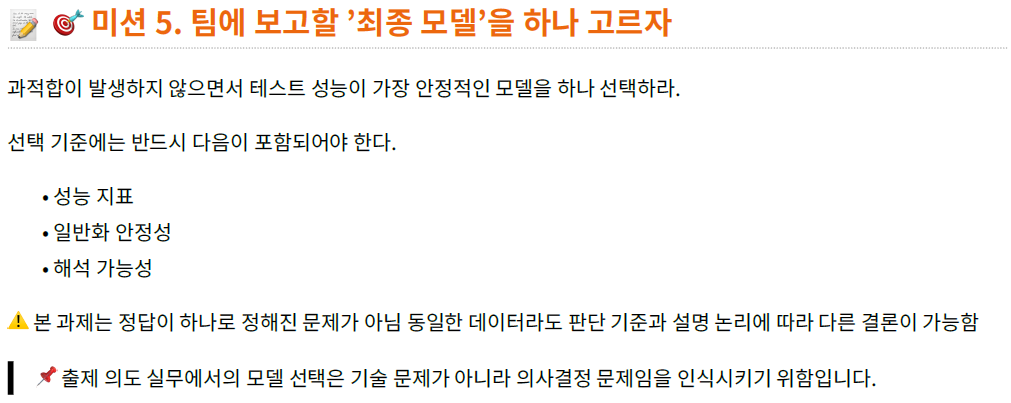

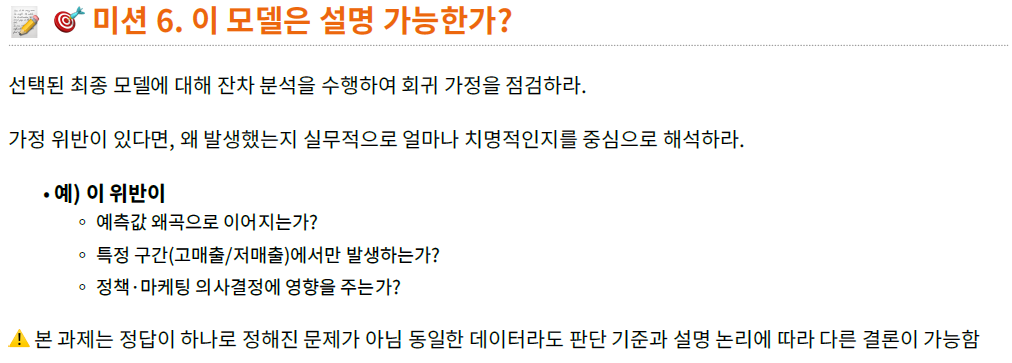

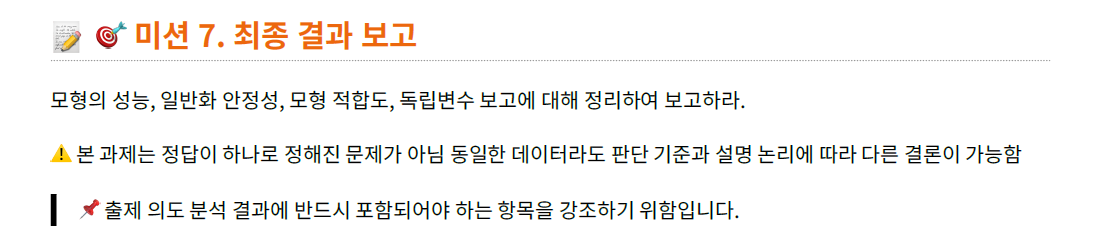